# Lecture 17: K-Nearest Neighbors (KNN)

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn KNN documentation](https://scikit-learn.org/stable/modules/neighbors.html)

---

### Learning objectives

By the end of this lecture you should be able to:

1. Explain the KNN algorithm for both classification and regression.
2. Compute Euclidean distance between data points and use it to find nearest neighbors.
3. Describe how the choice of $k$ affects the bias-variance tradeoff.
4. Explain why feature scaling is critical for KNN and apply it correctly.
5. Train, evaluate, and tune a KNN model in `scikit-learn`.
6. Apply KNN regression to predict ecosystem fluxes from meteorological data.


## 1. The Intuition: You Are Like Your Neighbors

The philosophy behind KNN is simple and ecological:

- **Organisms in similar environments tend to be similar** — this is why nearby plots on an environmental gradient often share species.
- **A pixel with similar spectral values to known forest pixels is probably forest too.**
- **If the 5 closest weather days to today all had high GPP, today's GPP is probably high as well.**

KNN formalizes this: to classify or predict for a new data point, look at the **$k$ nearest neighbors** in the training set and use their labels (or values) to make a prediction.

## 2. How KNN Works

### The algorithm

1. **Store** the entire training dataset (KNN has no real "training" phase).
2. Given a new point $\mathbf{x}_{\text{new}}$, **compute the distance** from $\mathbf{x}_{\text{new}}$ to every training point.
3. **Find the $k$ closest** training points (the $k$ nearest neighbors).
4. **For classification:** assign the class that is most common among the $k$ neighbors (majority vote).
   **For regression:** compute the mean (or median) of the $k$ neighbors' target values.

### Distance metric

The most common choice is **Euclidean distance**:

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{M} (x_j - x_j')^2}$$

Other options include Manhattan distance ($L_1$), Minkowski distance, and cosine similarity.

> **Important:** Since KNN depends entirely on distances, **features with larger magnitudes dominate the distance calculation**. This is why feature scaling is essential — we will demonstrate this later.


## 3. Building KNN from Scratch

Let's implement KNN manually to make sure we understand every step before using `scikit-learn`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.patches import Circle

# ── Generate a synthetic dataset ──
np.random.seed(42)
X = np.random.rand(20, 2) * 10  # 20 points in 2D space
y = np.random.choice([0, 1], size=20)  # Binary classification

# ── A new point to classify ──
query_point = np.array([5, 5])
k = 5

# ── Compute Euclidean distances ──
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

distances = np.array([euclidean_distance(query_point, x) for x in X])
neighbors_idx = np.argsort(distances)[:k]  # indices of k nearest neighbors
neighbor_labels = y[neighbors_idx]

# ── Majority vote ──
vote = Counter(neighbor_labels)
predicted_class = vote.most_common(1)[0][0]

print(f"Query point: {query_point}")
print(f"k = {k}")
print(f"Neighbor distances: {distances[neighbors_idx].round(2)}")
print(f"Neighbor labels:    {neighbor_labels}")
print(f"Vote counts:        {dict(vote)}")
print(f"Predicted class:    {predicted_class}")


Query point: [5 5]
k = 5
Neighbor distances: [1.94 1.97 2.2  2.31 2.47]
Neighbor labels:    [0 1 1 0 1]
Vote counts:        {np.int64(0): 2, np.int64(1): 3}
Predicted class:    1


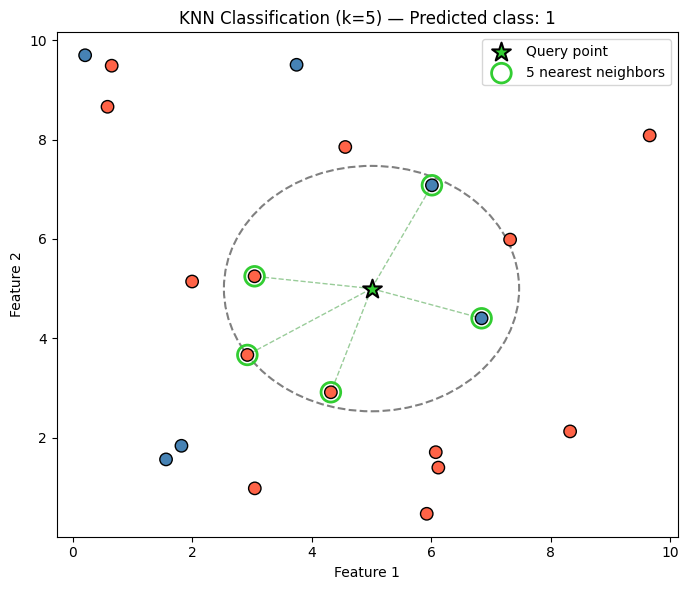

In [ ]:
# ── Visualize ──
fig, ax = plt.subplots(figsize=(7, 6))

# Training points
colors = ['steelblue' if label == 0 else 'tomato' for label in y]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=80, edgecolors='k', zorder=3)

# Query point
ax.scatter(*query_point, c='limegreen', s=200, marker='*',
           edgecolors='k', linewidths=1.5, zorder=4, label='Query point')

# Circle around k-th nearest neighbor (radius = distance to k-th neighbor)
radius = distances[neighbors_idx[-1]]
circle = Circle(query_point, radius, fill=False, linestyle='--',
                edgecolor='gray', linewidth=1.5)
ax.add_patch(circle)

# Highlight neighbors
ax.scatter(X[neighbors_idx, 0], X[neighbors_idx, 1],
           s=200, facecolors='none', edgecolors='limegreen',
           linewidths=2, zorder=3, label=f'{k} nearest neighbors')

# Lines from query to neighbors
for idx in neighbors_idx:
    ax.plot([query_point[0], X[idx, 0]],
            [query_point[1], X[idx, 1]],
            'g--', alpha=0.4, linewidth=1)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'KNN Classification (k={k}) — Predicted class: {predicted_class}')
ax.legend()
plt.tight_layout()
plt.show()


The green star is the query point. The dashed circle encloses its 5 nearest neighbors. The majority class among those neighbors becomes the prediction.


## 4. KNN Classification with `scikit-learn`

Let's use `sklearn`'s `KNeighborsClassifier` on synthetic data first, then on the Iris dataset.


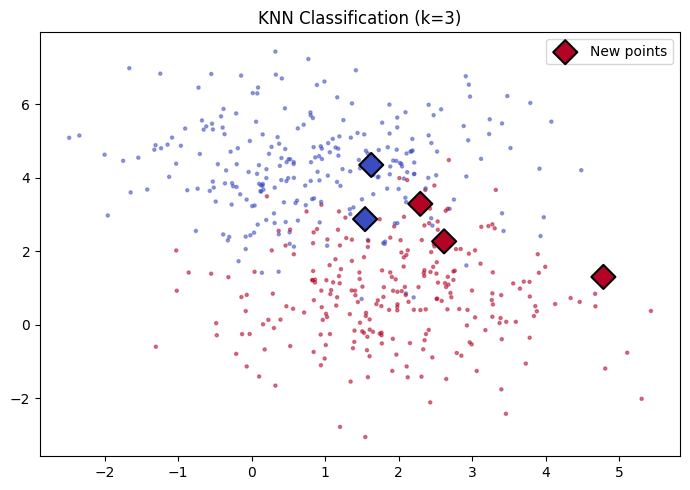

Predictions for new points: [1 1 0 0 1]


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# ── Synthetic two-class dataset ──
X, y = make_blobs(n_samples=500, centers=2, cluster_std=1.3, random_state=0)

# A few new points to classify
rng = np.random.RandomState(0)
X_new = [-1, -1] + [6, 6] * rng.rand(5, 2)

# ── Fit KNN ──
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)
y_pred_new = knn.predict(X_new)

# ── Plot ──
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=5, alpha=0.5)
ax.scatter(X_new[:, 0], X_new[:, 1], c=y_pred_new, cmap='coolwarm',
           s=150, edgecolors='k', linewidths=1.5, marker='D',
           label='New points')
ax.set_title('KNN Classification (k=3)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Predictions for new points: {y_pred_new}")


## 5. KNN for Regression

KNN isn't just for classification — it works for regression too. Instead of a majority vote, the prediction is the **mean of the $k$ neighbors' target values**:

$$
\hat{y} = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x})} y_i
$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of $k$ nearest neighbors of $\mathbf{x}$.


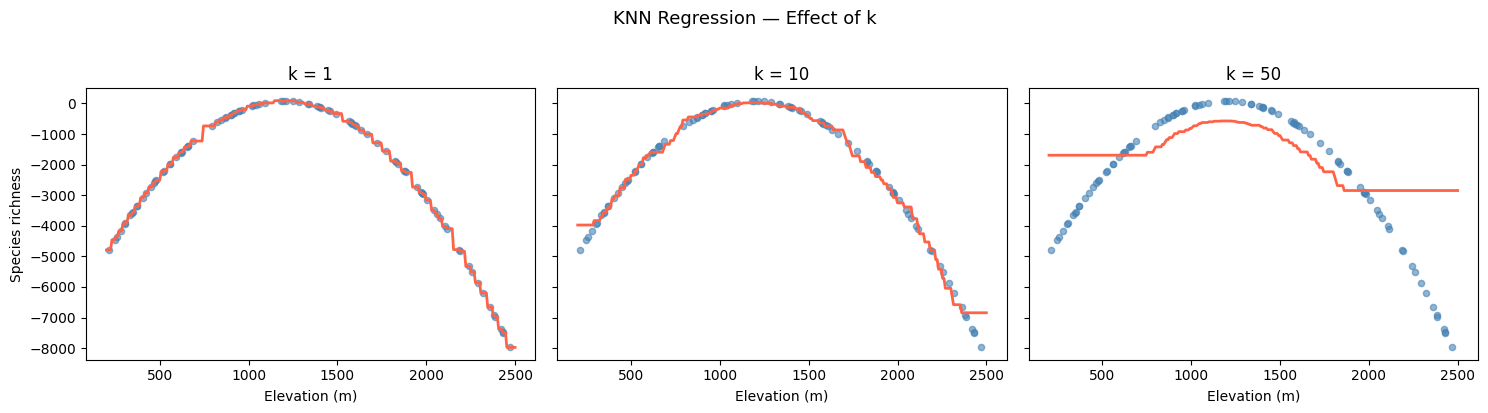

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt

# ── Synthetic 1D regression: species richness vs. elevation ──
np.random.seed(42)
n = 100
elevation = np.sort(np.random.uniform(200, 2500, n))
richness_true = -0.005 * (elevation - 1200)**2 + 80
richness = richness_true + np.random.normal(0, 8, n)

X_elev = elevation.reshape(-1, 1)
elev_fine = np.linspace(200, 2500, 300).reshape(-1, 1)

# ── Compare different k values ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, k in zip(axes, [1, 10, 50]):
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_elev, richness)
    y_fit = knn_reg.predict(elev_fine)

    ax.scatter(elevation, richness, color='steelblue', s=20, alpha=0.6)
    ax.plot(elev_fine, y_fit, color='tomato', linewidth=2)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Elevation (m)')

axes[0].set_ylabel('Species richness')
plt.suptitle('KNN Regression — Effect of k', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Notice the **bias-variance tradeoff** controlled by $k$:

- **$k = 1$**: the prediction is the value of the single nearest neighbor. Very noisy (high variance, low bias) — the curve follows every data point.
- **$k = 10$**: smoother, capturing the overall hump shape. A good balance.
- **$k = 50$**: very smooth (low variance, high bias) — the curve is over-smoothed and misses the peak.

This is directly analogous to the polynomial degree in Lecture 14 and the $C$ parameter in SVM (Lecture 15).


## 6. Choosing $k$: The Most Important Hyperparameter

The value of $k$ is the primary hyperparameter in KNN. We can find the best $k$ by evaluating performance on a test set across a range of values.


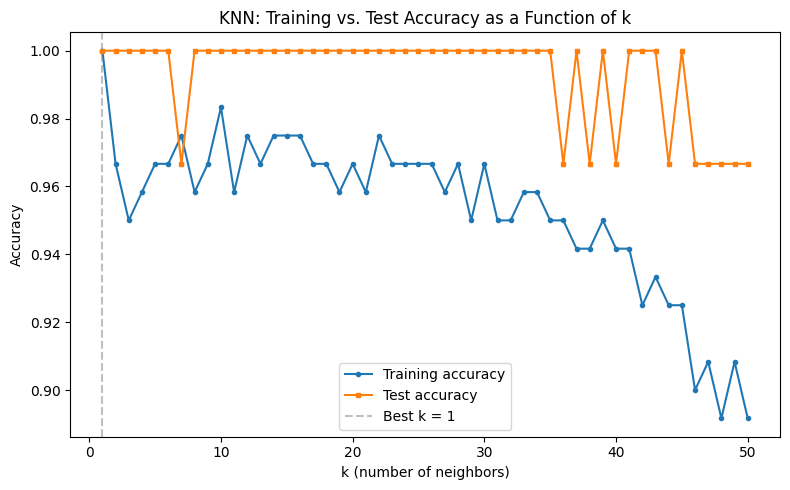

Best k on test set: 1 (accuracy = 100.00%)


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

# ── Iris dataset ──
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Sweep k from 1 to 50 ──
k_range = np.arange(1, 51)
train_acc = np.empty(len(k_range))
test_acc = np.empty(len(k_range))

for i, k in enumerate(k_range):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc[i] = knn.score(X_train, y_train)
    test_acc[i] = knn.score(X_test, y_test)

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, train_acc, 'o-', markersize=3, label='Training accuracy')
ax.plot(k_range, test_acc, 's-', markersize=3, label='Test accuracy')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: Training vs. Test Accuracy as a Function of k')
ax.legend()
ax.axvline(k_range[np.argmax(test_acc)], color='gray', linestyle='--', alpha=0.5,
           label=f'Best k = {k_range[np.argmax(test_acc)]}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best k on test set: {k_range[np.argmax(test_acc)]} "
      f"(accuracy = {test_acc.max():.2%})")


Key patterns to notice:

- **Training accuracy at $k=1$ is always 100%** — because the nearest neighbor of any training point is itself.
- **Test accuracy peaks at a moderate $k$** and then gradually declines as the model becomes too smooth.
- **The gap between training and test accuracy at low $k$** is a classic sign of overfitting.

In practice, use **cross-validation** rather than a single train/test split to select $k$ more robustly.


## 7. Why Feature Scaling Is Critical for KNN

KNN relies entirely on distances. If features have very different scales, the feature with the largest magnitude dominates the distance calculation — the other features are effectively ignored.

Let's demonstrate this with a real ecological example.


### Example: Predicting GPP from meteorological data

We'll use FLUXNET data from the Howland Forest (Maine) eddy-covariance tower — daily measurements of air temperature (TA), shortwave incoming radiation (SW_IN), and vapor pressure deficit (VPD) to predict gross primary productivity (GPP).

> **Note:** The data file is loaded from Google Drive. If running locally, adjust the file path accordingly.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load FLUXNET data ──
# Adjust this path to your environment
from google.colab import drive
drive.mount('/content/drive')

filedir = '/content/drive/MyDrive/'
fname = filedir + "FLX_US-Ho1_FLUXNET2015_SUBSET_DD_1996-2018_beta-3.csv"

Ho = pd.read_csv(fname)
Ho = Ho[["TIMESTAMP", "TA_F", "SW_IN_F", "VPD_F", "GPP_NT_VUT_REF"]]
Ho[Ho <= -9999] = None
Ho = Ho.dropna()

print(f"Dataset: Howland Forest (US-Ho1), daily data")
print(f"Samples: {len(Ho)}")
print(f"Features: TA_F (air temp, C), SW_IN_F (shortwave radiation, W/m2), VPD_F (VPD, hPa)")
print(f"Target:   GPP_NT_VUT_REF (gross primary productivity, gC/m2/day)")
print()
Ho.describe().round(2)


Mounted at /content/drive
Dataset: Howland Forest (US-Ho1), daily data
Samples: 2557
Features: TA_F (air temp, C), SW_IN_F (shortwave radiation, W/m2), VPD_F (VPD, hPa)
Target:   GPP_NT_VUT_REF (gross primary productivity, gC/m2/day)



,TIMESTAMP,TA_F,SW_IN_F,VPD_F,GPP_NT_VUT_REF
count,2557.00,2557.00,2557.00,2557.00,2557.00
mean,20150660.16,6.84,147.25,3.93,4.33
std,20009.01,10.76,95.71,3.50,3.75
min,20120101.00,-23.18,2.19,0.09,-0.57
25%,20131001.00,-1.27,66.70,1.12,0.38
50%,20150702.00,7.62,128.06,2.65,3.78
75%,20170401.00,16.55,226.11,5.89,7.91
max,20181231.00,27.62,368.04,19.89,12.88


Notice the feature magnitudes:

- Temperature (TA_F): roughly -20 to 25 °C
- Shortwave radiation (SW_IN_F): 0 to ~350 W/m²
- VPD: 0 to ~15 hPa

SW_IN_F values are ~20x larger than VPD values. If we run KNN without scaling, distances will be dominated by SW_IN_F.


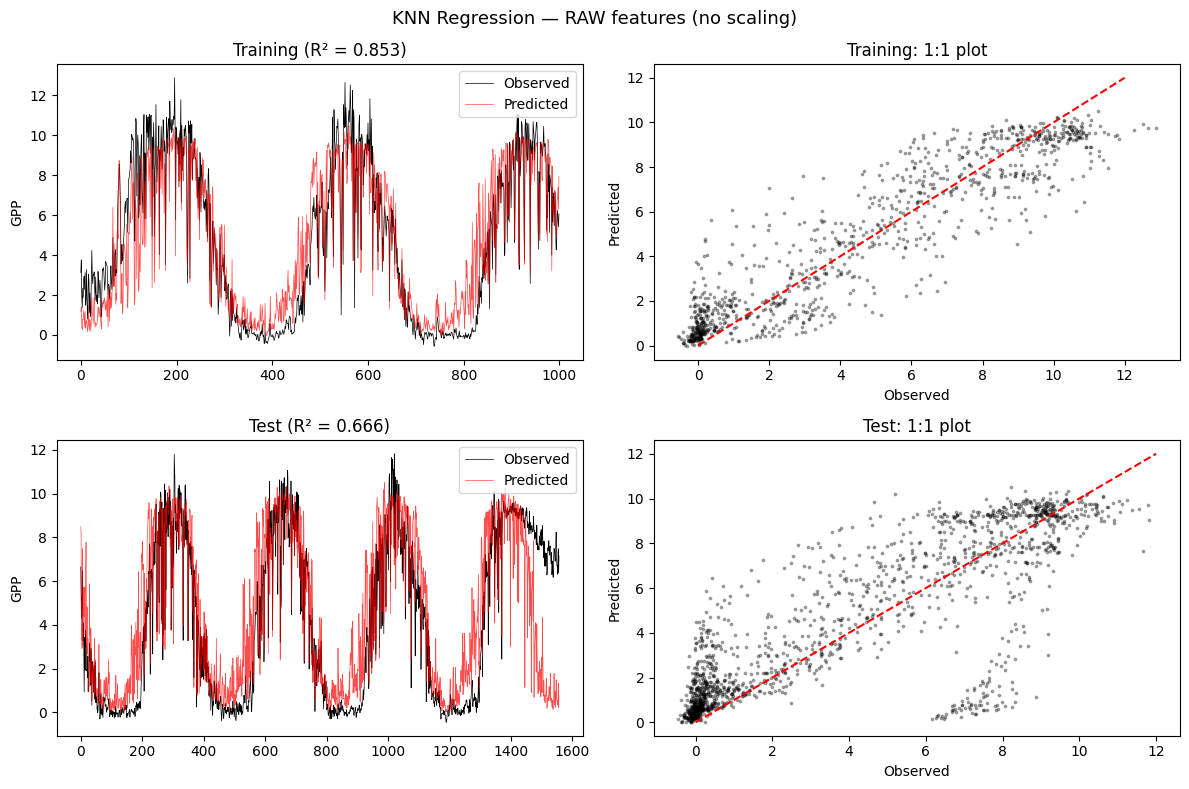

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import numpy as np

X = Ho[["TA_F", "SW_IN_F", "VPD_F"]].values
y = Ho["GPP_NT_VUT_REF"].values

# ── Chronological split (first 1000 days for training) ──
train_len = 1000
X_train, X_test = X[:train_len], X[train_len:]
y_train, y_test = y[:train_len], y[train_len:]

# ── KNN without scaling ──
knn_raw = KNeighborsRegressor(n_neighbors=20)
knn_raw.fit(X_train, y_train)
y_pred_raw_train = knn_raw.predict(X_train)
y_pred_raw_test = knn_raw.predict(X_test)

# ── Plot ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(y_train, 'k-', linewidth=0.5, label='Observed')
axes[0, 0].plot(y_pred_raw_train, 'r-', linewidth=0.5, alpha=0.7, label='Predicted')
axes[0, 0].set_title(f'Training (R² = {r2_score(y_train, y_pred_raw_train):.3f})')
axes[0, 0].set_ylabel('GPP')
axes[0, 0].legend()

axes[0, 1].scatter(y_train, y_pred_raw_train, s=3, alpha=0.3, color='k')
axes[0, 1].plot([0, 12], [0, 12], 'r--')
axes[0, 1].set_xlabel('Observed')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title('Training: 1:1 plot')

axes[1, 0].plot(y_test, 'k-', linewidth=0.5, label='Observed')
axes[1, 0].plot(y_pred_raw_test, 'r-', linewidth=0.5, alpha=0.7, label='Predicted')
axes[1, 0].set_title(f'Test (R² = {r2_score(y_test, y_pred_raw_test):.3f})')
axes[1, 0].set_ylabel('GPP')
axes[1, 0].legend()

axes[1, 1].scatter(y_test, y_pred_raw_test, s=3, alpha=0.3, color='k')
axes[1, 1].plot([0, 12], [0, 12], 'r--')
axes[1, 1].set_xlabel('Observed')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Test: 1:1 plot')

plt.suptitle('KNN Regression — RAW features (no scaling)', fontsize=13)
plt.tight_layout()
plt.show()


### What happens when we artificially distort the feature scales?

To make the point concrete, let's multiply VPD by 1000 and divide SW_IN by 1000. This shouldn't change the physical relationships — but it will dramatically change which features dominate the distance calculation.


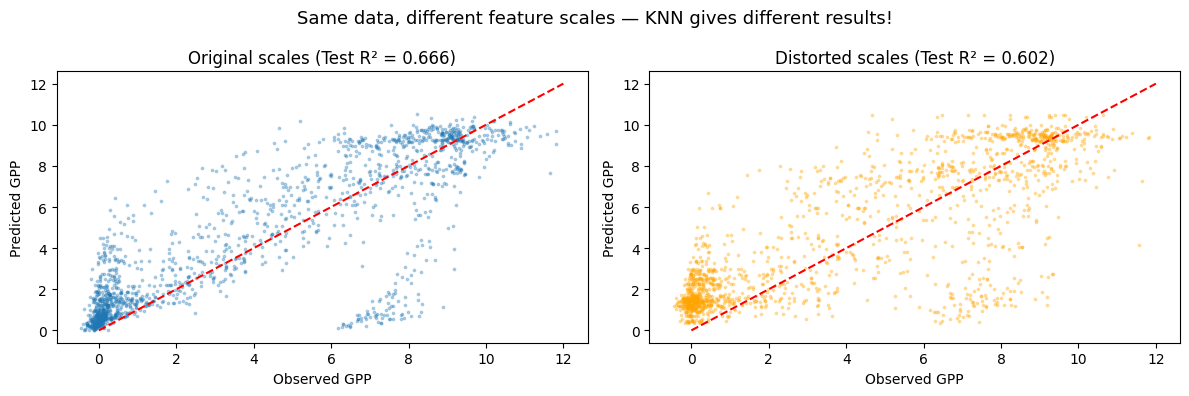

In [ ]:
# ── Deliberately distort scales ──
X_distorted = Ho[["TA_F", "SW_IN_F", "VPD_F"]].copy()
X_distorted["VPD_F"] = X_distorted["VPD_F"] * 1000      # inflate VPD
X_distorted["SW_IN_F"] = X_distorted["SW_IN_F"] / 1000   # shrink SW_IN
X_dist = X_distorted.values

X_train_d, X_test_d = X_dist[:train_len], X_dist[train_len:]

knn_dist = KNeighborsRegressor(n_neighbors=20)
knn_dist.fit(X_train_d, y_train)
y_pred_dist_test = knn_dist.predict(X_test_d)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_raw_test, s=3, alpha=0.3, label='Original scales')
axes[0].plot([0, 12], [0, 12], 'r--')
axes[0].set_title(f'Original scales (Test R² = {r2_score(y_test, y_pred_raw_test):.3f})')
axes[0].set_xlabel('Observed GPP')
axes[0].set_ylabel('Predicted GPP')

axes[1].scatter(y_test, y_pred_dist_test, s=3, alpha=0.3, color='orange',
                label='Distorted scales')
axes[1].plot([0, 12], [0, 12], 'r--')
axes[1].set_title(f'Distorted scales (Test R² = {r2_score(y_test, y_pred_dist_test):.3f})')
axes[1].set_xlabel('Observed GPP')
axes[1].set_ylabel('Predicted GPP')

plt.suptitle('Same data, different feature scales — KNN gives different results!', fontsize=13)
plt.tight_layout()
plt.show()


The predictions changed — even though the underlying data is identical! This demonstrates that **KNN is not scale-invariant**.

### The fix: normalize before fitting


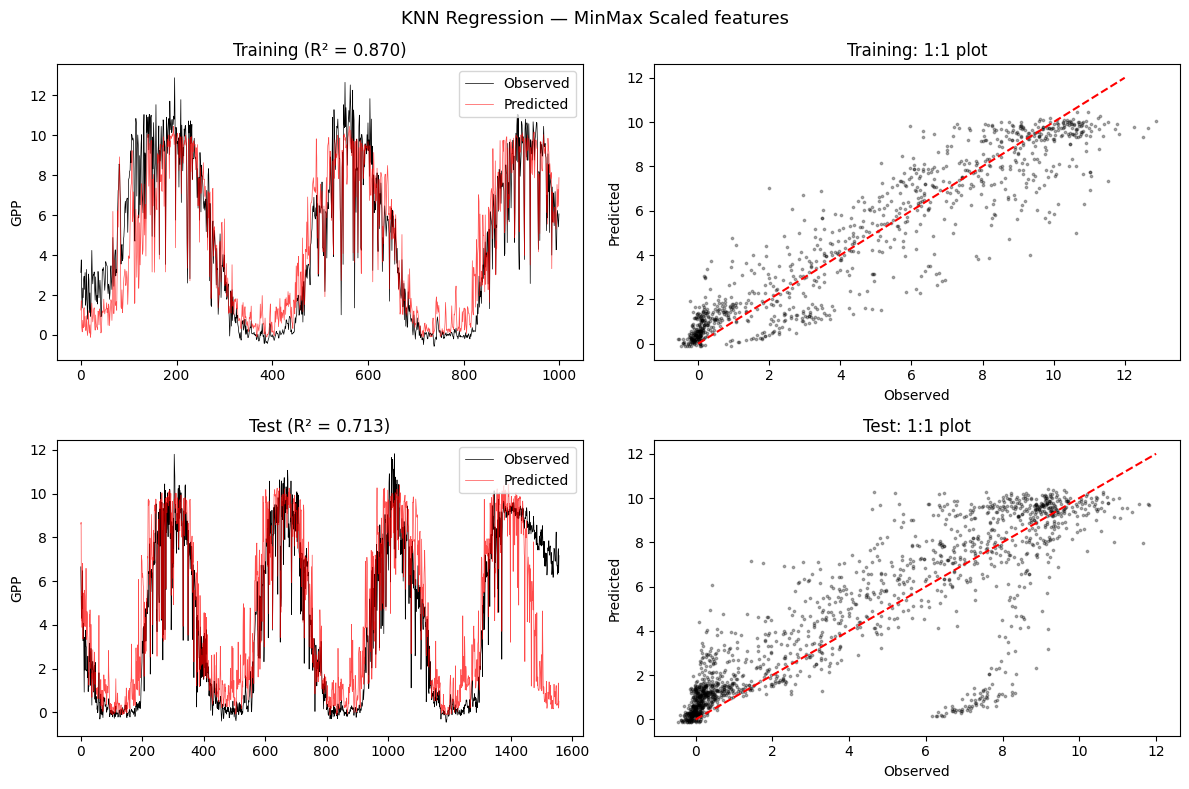

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ── Normalize all features to [0, 1] ──
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train_sc, X_test_sc = X_scaled[:train_len], X_scaled[train_len:]

knn_scaled = KNeighborsRegressor(n_neighbors=20)
knn_scaled.fit(X_train_sc, y_train)
y_pred_scaled_train = knn_scaled.predict(X_train_sc)
y_pred_scaled_test = knn_scaled.predict(X_test_sc)

# ── Plot comparison ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(y_train, 'k-', linewidth=0.5, label='Observed')
axes[0, 0].plot(y_pred_scaled_train, 'r-', linewidth=0.5, alpha=0.7, label='Predicted')
axes[0, 0].set_title(f'Training (R² = {r2_score(y_train, y_pred_scaled_train):.3f})')
axes[0, 0].set_ylabel('GPP')
axes[0, 0].legend()

axes[0, 1].scatter(y_train, y_pred_scaled_train, s=3, alpha=0.3, color='k')
axes[0, 1].plot([0, 12], [0, 12], 'r--')
axes[0, 1].set_xlabel('Observed')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title('Training: 1:1 plot')

axes[1, 0].plot(y_test, 'k-', linewidth=0.5, label='Observed')
axes[1, 0].plot(y_pred_scaled_test, 'r-', linewidth=0.5, alpha=0.7, label='Predicted')
axes[1, 0].set_title(f'Test (R² = {r2_score(y_test, y_pred_scaled_test):.3f})')
axes[1, 0].set_ylabel('GPP')
axes[1, 0].legend()

axes[1, 1].scatter(y_test, y_pred_scaled_test, s=3, alpha=0.3, color='k')
axes[1, 1].plot([0, 12], [0, 12], 'r--')
axes[1, 1].set_xlabel('Observed')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Test: 1:1 plot')

plt.suptitle('KNN Regression — MinMax Scaled features', fontsize=13)
plt.tight_layout()
plt.show()


With normalized features, all three variables (temperature, radiation, VPD) contribute equally to the distance calculation, giving more physically meaningful neighbors and better predictions.

> **Rule of thumb:** Always normalize features before using KNN (and SVM with RBF kernels). Two common approaches are MinMax scaling ($[0, 1]$) and z-score standardization (mean=0, std=1).


## 8. Pros and Cons of KNN

| Strengths | Limitations |
|---|---|
| Simple to understand and implement | Slow prediction for large datasets (must compute all distances) |
| No training phase — instantly adapts to new data | Memory-intensive — stores the entire training set |
| Works for both classification and regression | Sensitive to irrelevant or redundant features |
| Naturally handles multi-class problems | Requires feature scaling |
| Non-parametric — no assumptions about data distribution | Performance degrades in high dimensions ("curse of dimensionality") |

### The curse of dimensionality

In high-dimensional spaces, all points tend to be approximately equidistant from each other. This means the concept of "nearest neighbor" becomes less meaningful. If you have hundreds of features, KNN may struggle — consider dimensionality reduction (PCA) first, or use a tree-based method that is less affected by irrelevant features.


## 9. Comparing KNN to Other Classifiers


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
import numpy as np

X, y = load_iris(return_X_y=True)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM (RBF)":           SVC(kernel="rbf"),
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
}

print(f"{'Classifier':<25s}  {'Mean accuracy':>14s}  {'Std':>6s}")
print("-" * 50)

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    print(f"{name:<25s}  {scores.mean():>13.3f}  {scores.std():>6.3f}")


Classifier                  Mean accuracy     Std
--------------------------------------------------
Logistic Regression                0.973   0.025
SVM (RBF)                          0.967   0.021
Gaussian Naive Bayes               0.953   0.027
KNN (k=5)                          0.973   0.025


On the small, clean Iris dataset all four classifiers perform well. The real differences appear with messier, higher-dimensional data. Each algorithm has its sweet spot:

- **Logistic regression / linear SVM:** fast, interpretable, work well when decision boundaries are approximately linear.
- **RBF SVM:** powerful nonlinear classifier, but slow for large datasets and requires careful tuning of $C$ and $\gamma$.
- **Naive Bayes:** extremely fast, great baseline, but assumes feature independence.
- **KNN:** simple and nonparametric, but slow at prediction time and sensitive to scaling and dimensionality.


## 10. Summary

| Concept | Key takeaway |
|---|---|
| KNN algorithm | Classify/predict by majority vote (or mean) of $k$ nearest training points |
| Distance metric | Euclidean distance is default; features must be on the same scale |
| Choosing $k$ | Small $k$ = complex (overfitting); large $k$ = smooth (underfitting) |
| Feature scaling | **Mandatory** — use MinMaxScaler or StandardScaler |
| Classification | `KNeighborsClassifier` — majority vote |
| Regression | `KNeighborsRegressor` — mean of neighbors' values |
| Strengths | Simple, no assumptions, works for both tasks |
| Weaknesses | Slow prediction, memory-intensive, struggles in high dimensions |

### Algorithms covered so far

| Lecture | Algorithm | Type | Key idea |
|---|---|---|---|
| 14 | Linear regression | Regression | Minimize MSE with a linear function |
| 14 | Logistic regression | Classification | Linear model + sigmoid → probabilities |
| 15 | SVM | Classification | Maximize the margin between classes |
| 16 | Naive Bayes | Classification | Bayes' theorem + feature independence assumption |
| 17 | KNN | Both | Predict from the $k$ closest training examples |
